Load model and turn sample mechanism descriptions into embeddings:

In [ ]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

# Example texts
mechanisms = [
    "reduce pain via COX-2 inhibition",
    "block HMG-CoA reductase to lower cholesterol",
    "antagonize histamine H1 receptors for allergy relief"
]

# Tokenize and generate embeddings
for text in mechanisms:
    inputs = tokenizer(text, return_tensors="pt")
    outputs = model(**inputs)
    # Take mean of last_hidden_state across tokens for a single vector per sentence
    embedding = outputs.last_hidden_state.mean(dim=1)
    print(f"Text: {text}")
    print(f"Embedding shape: {embedding.shape}\n")

Text: reduce pain via COX-2 inhibition
Embedding shape: torch.Size([1, 768])

Text: block HMG-CoA reductase to lower cholesterol
Embedding shape: torch.Size([1, 768])

Text: antagonize histamine H1 receptors for allergy relief
Embedding shape: torch.Size([1, 768])



## Test with examples

In [ ]:
text = "reduce pain via COX-2 inhibition"
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)
embedding = outputs.last_hidden_state.mean(dim=1)
print("Embedding shape:", embedding.shape)

Embedding shape: torch.Size([1, 768])


## Exploratory Data Analysis

In [ ]:
import pandas as pd

mechanisms = [
    "reduce pain via COX-2 inhibition",
    "block HMG-CoA reductase to lower cholesterol",
    "antagonize histamine H1 receptors for allergy relief",
    "inhibit viral protease to prevent replication",
    "block sodium channels to reduce nerve firing",
    "enhance dopamine reuptake for mood regulation",
    "activate GABA-A receptor for sedation",
    "inhibit acetylcholinesterase to improve cognition",
    "reduce oxidative stress via free radical scavenging",
    "inhibit angiotensin converting enzyme to lower blood pressure"
]

df = pd.DataFrame({"mechanism": mechanisms})
df.head()

,mechanism
0,reduce pain via COX-2 inhibition
1,block HMG-CoA reductase to lower cholesterol
2,antagonize histamine H1 receptors for allergy ...
3,inhibit viral protease to prevent replication
4,block sodium channels to reduce nerve firing


### Dataset Overview

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (10, 1)

Column names: Index(['mechanism'], dtype='object')

First few rows:
                                           mechanism
0                   reduce pain via COX-2 inhibition
1       block HMG-CoA reductase to lower cholesterol
2  antagonize histamine H1 receptors for allergy ...
3      inhibit viral protease to prevent replication
4       block sodium channels to reduce nerve firing


In [ ]:
df["word_count"] = df["mechanism"].apply(lambda x: len(x.split()))
df["char_count"] = df["mechanism"].apply(len)

print(df.describe())

       word_count  char_count
count   10.000000   10.000000
mean     6.200000   46.000000
std      1.032796    8.041559
min      5.000000   32.000000
25%      5.250000   44.000000
50%      6.000000   45.000000
75%      7.000000   50.500000
max      8.000000   61.000000


In [ ]:
from collections import Counter

all_words = " ".join(df["mechanism"]).split()
word_freq = Counter(all_words)

print("Most common words:")
print(word_freq.most_common(10))

Most common words:
[('to', 5), ('reduce', 3), ('for', 3), ('inhibit', 3), ('via', 2), ('block', 2), ('lower', 2), ('pain', 1), ('COX-2', 1), ('inhibition', 1)]


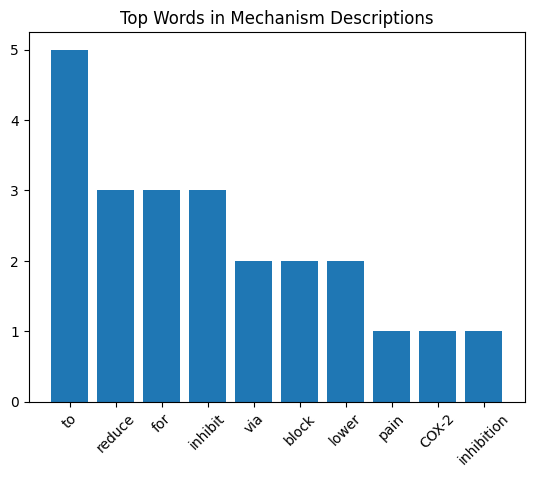

In [ ]:
import matplotlib.pyplot as plt

words = [w[0] for w in word_freq.most_common(10)]
counts = [w[1] for w in word_freq.most_common(10)]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words in Mechanism Descriptions")
plt.show()

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")

embeddings = []

for text in df["mechanism"]:
    inputs = tokenizer(text, return_tensors="pt")
    outputs = model(**inputs)
    emb = outputs.last_hidden_state.mean(dim=1).detach().numpy()
    embeddings.append(emb[0])

import numpy as np
embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding shape: (10, 768)


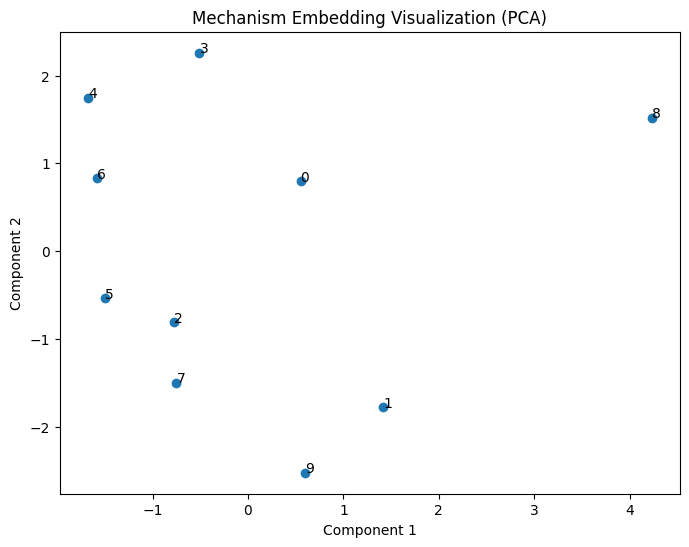

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1])

for i, txt in enumerate(df["mechanism"]):
    plt.annotate(i, (reduced[i,0], reduced[i,1]))

plt.title("Mechanism Embedding Visualization (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

pd.DataFrame(similarity_matrix, columns=df["mechanism"], index=df["mechanism"])

mechanism,reduce pain via COX-2 inhibition,block HMG-CoA reductase to lower cholesterol,antagonize histamine H1 receptors for allergy relief,inhibit viral protease to prevent replication,block sodium channels to reduce nerve firing,enhance dopamine reuptake for mood regulation,activate GABA-A receptor for sedation,inhibit acetylcholinesterase to improve cognition,reduce oxidative stress via free radical scavenging,inhibit angiotensin converting enzyme to lower blood pressure
mechanism,,,,,,,,,,
reduce pain via COX-2 inhibition,1.000000,0.869215,0.896335,0.854170,0.896002,0.887259,0.908291,0.892676,0.880946,0.882868
block HMG-CoA reductase to lower cholesterol,0.869215,1.000000,0.860380,0.840914,0.841297,0.874392,0.866554,0.892216,0.854188,0.896429
antagonize histamine H1 receptors for allergy relief,0.896335,0.860380,0.999999,0.835964,0.861131,0.893989,0.900415,0.902493,0.823630,0.873619
inhibit viral protease to prevent replication,0.854170,0.840914,0.835964,1.000000,0.866888,0.851582,0.856839,0.851744,0.811299,0.838430
block sodium channels to reduce nerve firing,0.896002,0.841297,0.861131,0.866888,1.000000,0.879141,0.913769,0.888350,0.813822,0.852002
enhance dopamine reuptake for mood regulation,0.887259,0.874392,0.893989,0.851582,0.879141,0.999999,0.927359,0.919852,0.818875,0.869471
activate GABA-A receptor for sedation,0.908291,0.866554,0.900415,0.856839,0.913769,0.927359,1.000000,0.904886,0.830388,0.849473
inhibit acetylcholinesterase to improve cognition,0.892676,0.892216,0.902493,0.851744,0.888350,0.919852,0.904886,1.000000,0.833762,0.912752
reduce oxidative stress via free radical scavenging,0.880946,0.854188,0.823630,0.811299,0.813822,0.818875,0.830388,0.833762,1.000000,0.826307
